<a href="https://colab.research.google.com/github/korzhimanov/dsp-seminars/blob/main/seminars/4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №4

## Случайные сигналы, шумы и спектральная плотность мощности

## Задание 1. Генерация белого, розового и красного шума
Сгенерируйте три сигнала длительностью 2 секунды с частотой дискретизации 1000 Гц:
- Белый гауссов шум с нулевым средним и дисперсией 1.
- Розовый шум – возьмите Фурье-преобразование от белого шума, домножьте его на функцию $1/\sqrt{f}$ и возьмите обратное Фурье-преобразование, результат нормализуйте.
- красный шум – кумулятивная сумма белого шума (нормалиованная).

Постройте временные графики всех трёх сигналов. Вычислите и выведите их средние значения и дисперсии.


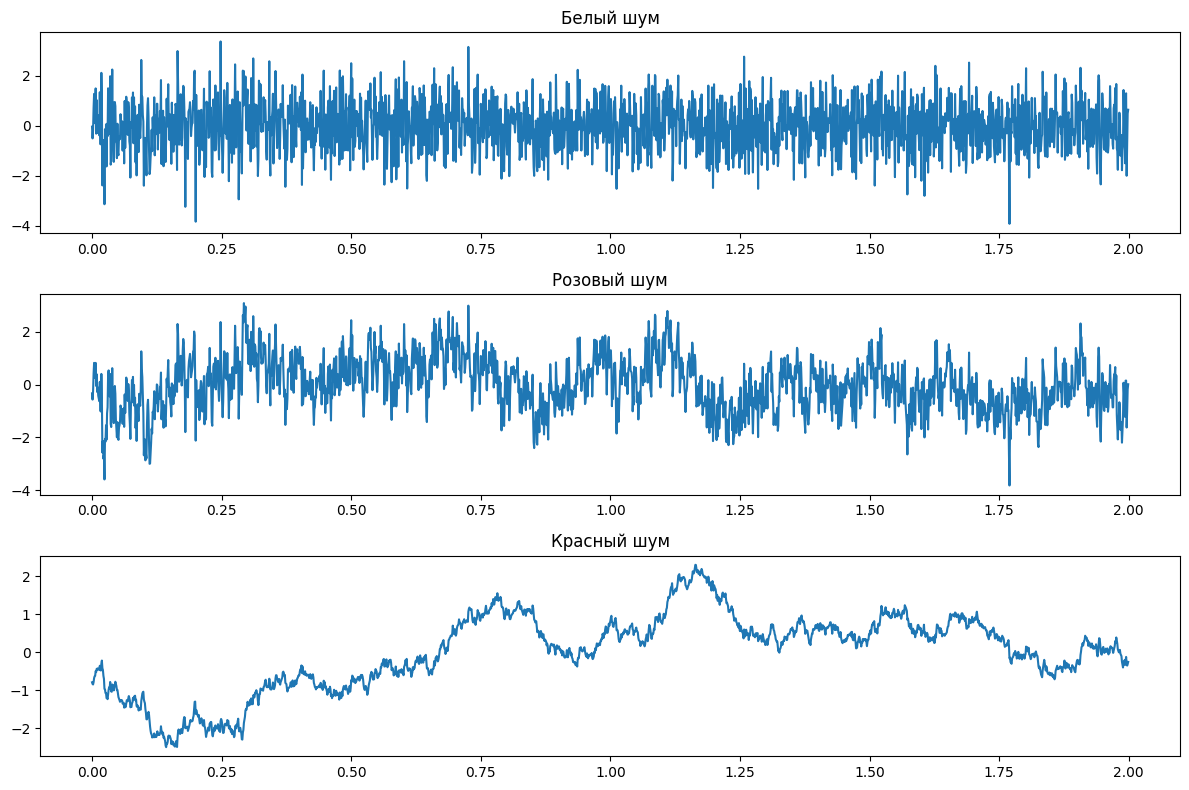

Белый шум:   mean = 0.0031537952334835 var = 0.9767383644563618
Розовый шум: mean = 0.0 var = 1.0
Красный шум: mean = 1.1368683772161603e-16 var = 1.0000000000000002


In [72]:
import numpy as np
import matplotlib.pyplot as plt

fs = 1000
T = 2
N = fs * T
t = np.arange(N) / fs

white_noise = np.random.normal(0, 1, N)

white_fft = np.fft.rfft(white_noise)
freqs = np.fft.rfftfreq(N, d=1/fs)

scaling = np.ones_like(freqs)
scaling[1:] = 1 / np.sqrt(freqs[1:])
scaling[0] = 0

pink_fft = white_fft * scaling
pink_noise = np.fft.irfft(pink_fft, n=N)

pink_noise = (pink_noise - np.mean(pink_noise)) / np.std(pink_noise)

red_noise = np.cumsum(white_noise)
red_noise = (red_noise - np.mean(red_noise)) / np.std(red_noise)

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t, white_noise)
plt.title("Белый шум")

plt.subplot(3, 1, 2)
plt.plot(t, pink_noise)
plt.title("Розовый шум")

plt.subplot(3, 1, 3)
plt.plot(t, red_noise)
plt.title("Красный шум")

plt.tight_layout()
plt.show()

print("Белый шум:   mean =", np.mean(white_noise), "var =", np.var(white_noise))
print("Розовый шум: mean =", np.mean(pink_noise), "var =", np.var(pink_noise))
print("Красный шум: mean =", np.mean(red_noise), "var =", np.var(red_noise))

**Вопрос:** Как визуально отличаются разные виды шума? Совпадают ли вычисленные средние и дисперсии сигналов от теоретических? Если отличаются, объясните почему.


Белый шум - резкие и частые скачки.
Розовый шум - более медленные скачки но всё ищё присутствуют скачки.
Красный шум - выглидт сглаженным, скачки не заметны.

Среднее у всех сигналов около 0, а дисперсия близка к 1.

Есть небольшие отклонения от теоретических. Связано с длиной сигнала и случайного характера шума.

## Задание 2. Вычисление автокорреляционной функции (АКФ)
Для каждого из сгенерированных шумов вычислите автокорреляционную функцию (с помощью `np.correlate(x, x, mode='full')`). Возьмите только положительные сдвиги (или сдвиги от -N+1 до N-1, но визуализируйте симметричную часть). Постройте графики нормированных АКФ (поделите на значение при нулевом сдвиге) для всех трёх шумов на одном рисунке.


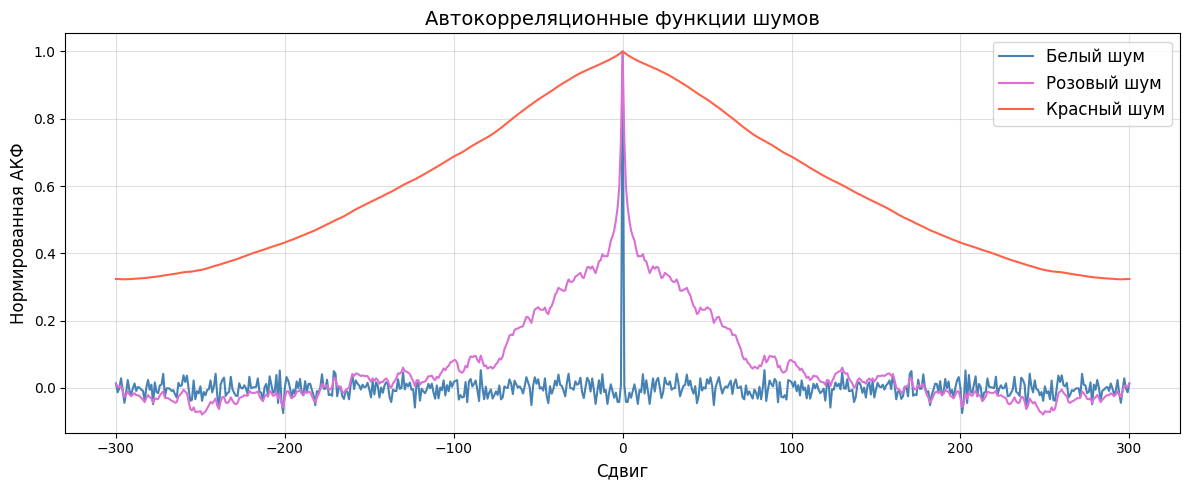

In [73]:


np.random.seed(42)
noise_map = {
    'Белый шум':   white_noise,
    'Розовый шум': pink_noise,
    'Красный шум': red_noise,
}

def compute_acf(x):
    acf  = np.correlate(x, x, mode='full')
    acf  = acf / acf[len(x) - 1]
    lags = np.arange(-len(x) + 1, len(x))
    return lags, acf

lag_limit = 300
colors    = ['steelblue', 'orchid', 'tomato']

plt.figure(figsize=(12, 5))

for (name, signal), color in zip(noise_map.items(), colors):
    lags, acf = compute_acf(signal)
    mask = np.abs(lags) <= lag_limit
    plt.plot(lags[mask], acf[mask], label=name, color=color, linewidth=1.5)

plt.title('Автокорреляционные функции шумов', fontsize=14)
plt.xlabel('Сдвиг', fontsize=12)
plt.ylabel('Нормированная АКФ', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

**Вопрос:** Сравнив АКФ и временную развёртку для разных видов шума, сделайте вывод о том, как форма АКФ связана с гладкостью сигнала.


У белого шума АКФ почти сразу падает к нулю, поэтому сигнал выглядит самым резким и хаотичным.

У розового шума АКФ шире, соседние отсчёты сильнее связаны и сигнал более плавный.

У красного шума АКФ самая широкая, сигнал наиболее сглаженный и медленно меняющийся.

Получается чем более гладкий шум, тем шире и медленнее спадает его АКФ.

## Задание 3. Оценка спектральной плотности мощности (СПМ). Периодограмма и метод Уэлча
Для каждого типа шума вычислите:
- Периодограмму с помощью `scipy.signal.periodogram`.
- Оценку СПМ методом Уэлча с помощью `scipy.signal.welch` с параметрами `nperseg=256`, `noverlap=128`, окно Ханна.

Постройте на одном графике (для каждого шума отдельно) периодограмму и оценку Уэлча в двойном логарифмическом масштабе по оси Y (используйте `plt.loglog`).


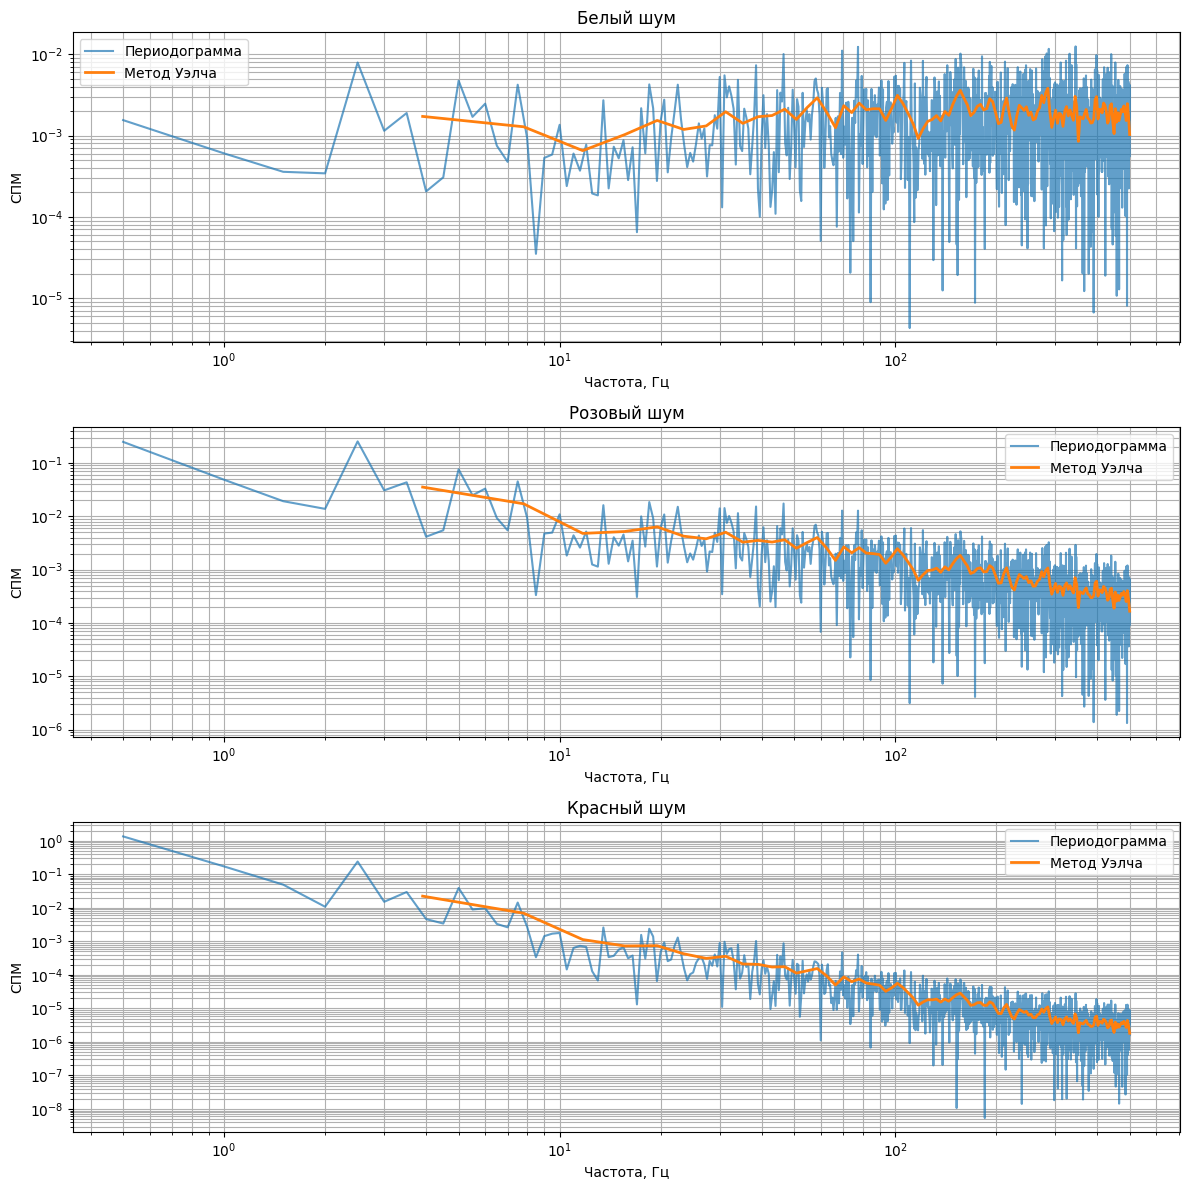

In [74]:
from scipy.signal import periodogram, welch
import matplotlib.pyplot as plt

signals = {
    'Белый': white_noise,
    'Розовый': pink_noise,
    'Красный': red_noise
}

plt.figure(figsize=(12, 12))

for i, (name, sig) in enumerate(signals.items(), 1):
    f_per, P_per = periodogram(sig, fs=fs)
    f_welch, P_welch = welch(sig, fs=fs, window='hann', nperseg=256, noverlap=128)
    plt.subplot(3, 1, i)
    plt.loglog(f_per[1:], P_per[1:], alpha=0.7, label='Периодограмма')
    plt.loglog(f_welch[1:], P_welch[1:], linewidth=2, label='Метод Уэлча')
    plt.title(f'{name} шум')
    plt.xlabel('Частота, Гц')
    plt.ylabel('СПМ')
    plt.grid(True, which='both')
    plt.legend()

plt.tight_layout()
plt.show()

**Вопрос:** Как выглядят зависимости СПМ от частоты у разных видов шума в двойном логарифмическом масштабе? Как они должны выглядеть теоретически?


Белый шум: выглядит как горизонтальная линия. Это означает, что мощность одинакова на всех частотах. Это соотвествует теоретической зависимости S(f) = константа.

Розовый шум: выглядит на графике как прямая линия, равномерно спадающая вниз c наклоном -1. Это соответсвует закону S(f)∼1/f для розового шума.

Красный шум имеет более быстрый спад S(f)∼1/f, что на графике соответствует прямой линии с наклоном около -2.

## Задание 4. Влияние длины сегмента в методе Уэлча
Для белого шума вычислите оценку СПМ методом Уэлча с разной длиной сегмента: `nperseg = 64, 128, 256, 512`. Используйте окно Ханна, перекрытие 50%. Постройте все четыре оценки на одном графике (логарифмическая шкала по Y).


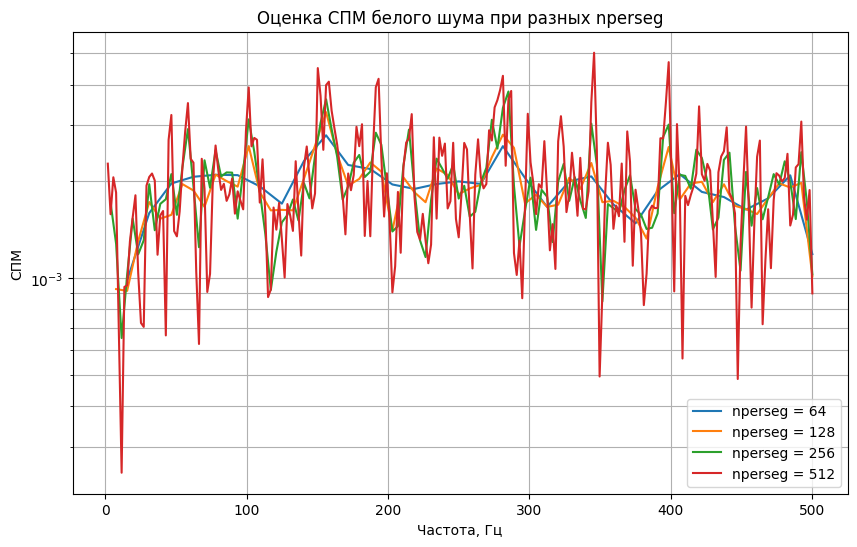

In [75]:
nperseg_values = [64, 128, 256, 512]

plt.figure(figsize=(10, 6))

for nperseg in nperseg_values:
    f, Pxx = welch(
        white_noise,
        fs=fs,
        window='hann',
        nperseg=nperseg,
        noverlap=nperseg // 2
    )
    plt.semilogy(f[1:], Pxx[1:], label=f'nperseg = {nperseg}')

plt.title('Оценка СПМ белого шума при разных nperseg')
plt.xlabel('Частота, Гц')
plt.ylabel('СПМ')
plt.grid(True, which='both')
plt.legend()
plt.show()

**Вопрос:** Как увеличение длины сегмента влияет на разрешение по частоте (ширину пиков) и гладкость оценки (дисперсию значений)?


При увеличении длины сегмента улучшается частотное разрешение, но оценка спектра становится менее гладкой. При уменьшении длины сегмента, наоборот, спектр сглаживается, но теряется детализация по частоте.

## Задание 5. Влияние дисперсии шума на его характеристики
Для каждого вида шума вычислите и выведите на один график при разных значениях дисперсии (например, 0.1, 1, 10):
1. Временную реализацию.
2. АКФ.
3. СПМ.

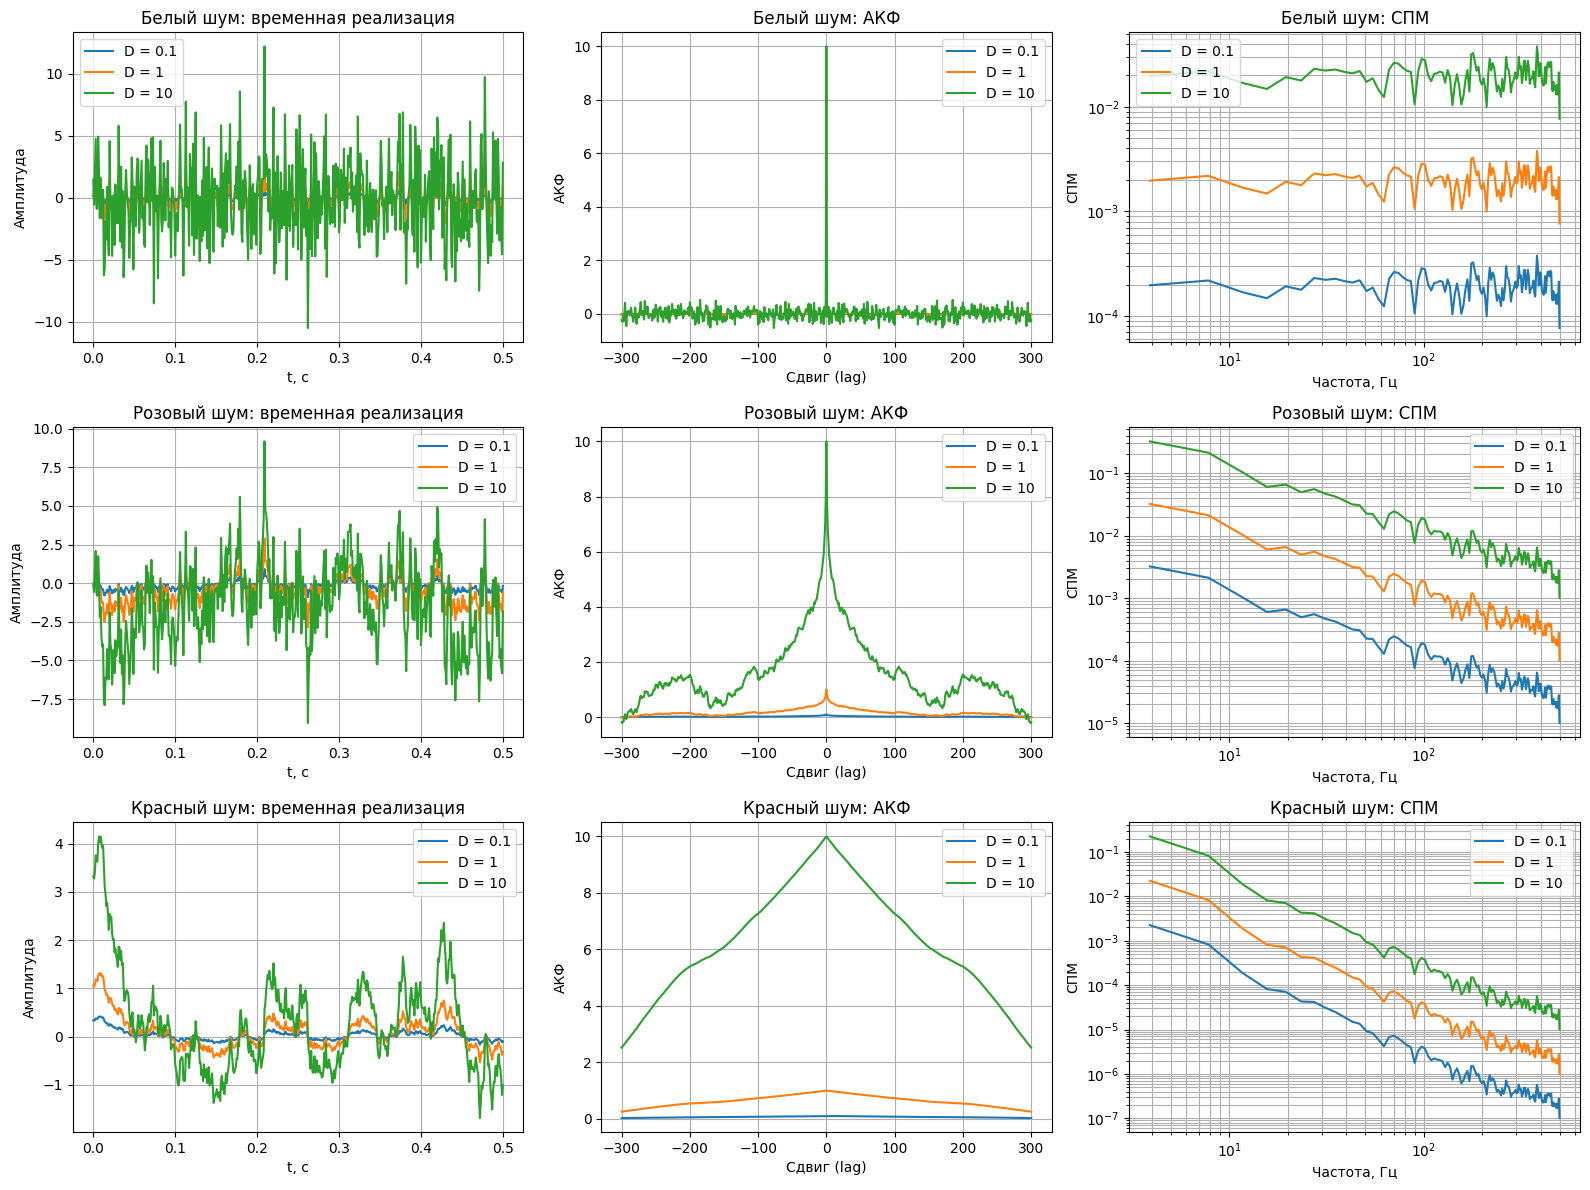

In [76]:
np.random.seed(42)

fs = 1000
T = 2.0
N = int(fs * T)
t = np.arange(N) / fs
variances = [0.1, 1, 10]

base_white = np.random.normal(0, 1, N)
base_white = (base_white - np.mean(base_white)) / np.std(base_white)

X_white = np.fft.rfft(base_white)
freqs = np.fft.rfftfreq(N, d=1/fs)
pink_filter = np.ones_like(freqs)
pink_filter[1:] = 1 / np.sqrt(freqs[1:])
pink_filter[0] = 0
X_pink = X_white * pink_filter
base_pink = np.fft.irfft(X_pink, n=N)
base_pink = (base_pink - np.mean(base_pink)) / np.std(base_pink)

base_red = np.cumsum(base_white)
base_red = (base_red - np.mean(base_red)) / np.std(base_red)

bases = {
    "Белый шум": base_white,
    "Розовый шум": base_pink,
    "Красный шум": base_red
}

def acf_raw(x, max_lag=300):
    acf = np.correlate(x, x, mode='full') / len(x)
    lags = np.arange(-len(x) + 1, len(x))
    mask = np.abs(lags) <= max_lag
    return lags[mask], acf[mask]

plt.figure(figsize=(16, 12))

for row, (name, base_signal) in enumerate(bases.items()):
    plt.subplot(3, 3, row*3 + 1)
    plt.subplot(3, 3, row*3 + 2)
    plt.subplot(3, 3, row*3 + 3)

    for var in variances:
        x = base_signal * np.sqrt(var)

        plt.subplot(3, 3, row*3 + 1)
        mask_t = t <= 0.5
        plt.plot(t[mask_t], x[mask_t], label=f'D = {var}')

        plt.subplot(3, 3, row*3 + 2)
        lags, acf_vals = acf_raw(x, max_lag=300)
        plt.plot(lags, acf_vals, label=f'D = {var}')

        plt.subplot(3, 3, row*3 + 3)
        f, Pxx = welch(x, fs=fs, nperseg=256, noverlap=128, window='hann')
        plt.loglog(f[1:], Pxx[1:], label=f'D = {var}')

    plt.subplot(3, 3, row*3 + 1)
    plt.title(f'{name}: временная реализация')
    plt.xlabel('t, c')
    plt.ylabel('Амплитуда')
    plt.grid()
    plt.legend()

    plt.subplot(3, 3, row*3 + 2)
    plt.title(f'{name}: АКФ')
    plt.xlabel('Сдвиг (lag)')
    plt.ylabel('АКФ')
    plt.grid()
    plt.legend()

    plt.subplot(3, 3, row*3 + 3)
    plt.title(f'{name}: СПМ')
    plt.xlabel('Частота, Гц')
    plt.ylabel('СПМ')
    plt.grid(True, which='both')
    plt.legend()

plt.tight_layout()
plt.show()

**Вопрос:** Что меняется при изменении дисперсии в каждом случае?


При изменении дисперсии меняется только масштаб сигнала, а структура остаётся прежней.

В АКФ форма остаётся той же, но значения увеличиваются пропорционально дисперсии.

В СПМ спектр поднимается вверх, но его наклон не меняется.

## Задание 6. Обнаружение гармонического сигнала на фоне шума. Спектральный анализ зашумлённой синусоиды
Сгенерируйте сигнал длительностью 2 секунды (fs=1000 Гц), состоящий из:
- синусоиды частотой 110 Гц с амплитудой 1,
- белого гауссова шума с дисперсией, обеспечивающей отношение сигнал/шум (SNR) = 10 дБ.

SNR (дБ) = $10 \log_{10}(P_{signal}/P_{noise})$.

1. Оцените СПМ с помощью метода Уэлча (выберите `nperseg` так, чтобы частота 110 Гц была хорошо разрешена). Определите частоту пика и сравните с истинной.
2. Повторите для других значений SNR ($0$ дБ, $-10$ дБ, $-20$ дБ и т. д.)


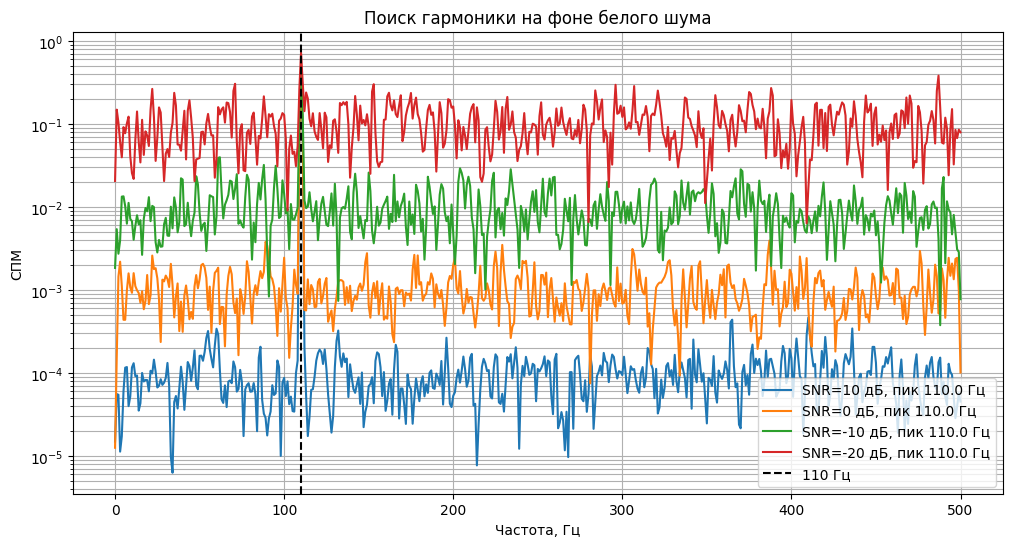

SNR, дБ | Найденный максимум, Гц | Ошибка, Гц
     10 |                   110.0 |        0.0
      0 |                   110.0 |        0.0
    -10 |                   110.0 |        0.0
    -20 |                   110.0 |        0.0


In [79]:
from scipy.signal import welch

rng = np.random.default_rng(555)

f0 = 110
amp = 1.0
pure_tone = amp * np.sin(2 * np.pi * f0 * t)
signal_power = amp**2 / 2

snr_list = [10, 0, -10, -20]
seg_len = 1000

plt.figure(figsize=(12, 6))
detected = []

for snr_db in snr_list:
    snr_lin = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_lin
    sigma = np.sqrt(noise_power)

    noisy = pure_tone + rng.normal(0.0, sigma, size=N)

    f_w, s_w = welch(
        noisy,
        fs=fs,
        window="hann",
        nperseg=seg_len,
        noverlap=seg_len // 2
    )

    peak_id = np.argmax(s_w)
    peak_freq = f_w[peak_id]
    detected.append((snr_db, peak_freq))
    plt.semilogy(f_w, s_w, label=f"SNR={snr_db} дБ, пик {peak_freq:.1f} Гц")

plt.axvline(f0, color="k", linestyle="--", label="110 Гц")
plt.title("Поиск гармоники на фоне белого шума")
plt.xlabel("Частота, Гц")
plt.ylabel("СПМ")
plt.grid(True, which="both")
plt.legend()
plt.show()

print("SNR, дБ | Найденный максимум, Гц | Ошибка, Гц")
for snr_db, peak_freq in detected:
    print(f"{snr_db:7d} | {peak_freq:23.1f} | {abs(peak_freq - f0):10.1f}")

**Вопрос:** Как меняется видимость пика на спектре при изменении SNR? При каком SNR пик ещё можно уверенно обнаружить визуально?


При уменьшении SNR пик на 110 Гц всё хуже выделяется на фоне шума: шумовой уровень растёт, а контраст спектрального максимума уменьшается. Видно, что максимум остаётся на нужной частоте даже при -20 дБ, но визуально он уже заметно менее выразителен, чем при 10 и 0 дБ.

Пик различим вплоть до -20 дБ, хотя уверенность в оценке уже ниже.

## Задание 7. Разрешение двух близких частот
Сгенерируйте сигнал, содержащий две синусоиды с частотами 100 и 110 Гц, равными амплитудами 1, и белый шум с дисперсией 0.1. Длительность сигнала 1 секунда, fs=1000 Гц. Используйте метод Уэлча с разными длинами сегмента: 128, 256, 512. Постройте оценки СПМ для каждого случая.


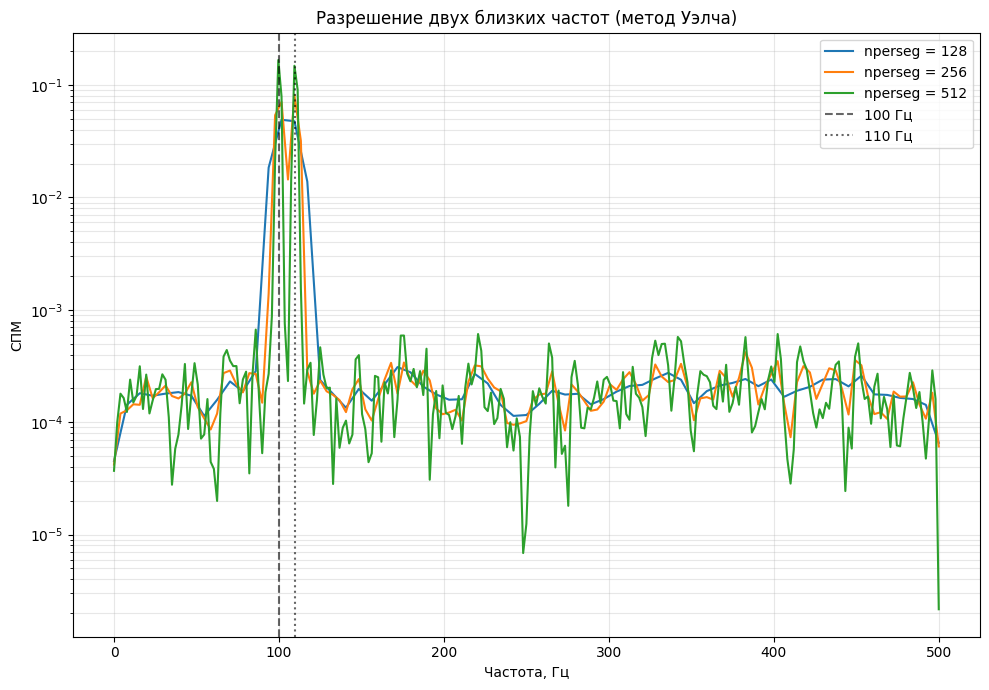

nperseg = 128 → Δf ≈ 7.81 Гц
nperseg = 256 → Δf ≈ 3.91 Гц
nperseg = 512 → Δf ≈ 1.95 Гц


In [80]:

fs = 1000
T = 1
N = int(fs * T)
t = np.arange(N) / fs

f1, f2 = 100, 110
A = 1
noise_var = 0.1

np.random.seed(42)


signal = (A * np.sin(2 * np.pi * f1 * t) +
          A * np.sin(2 * np.pi * f2 * t))

noise = np.sqrt(noise_var) * np.random.randn(N)
x = signal + noise


segment_lengths = [128, 256, 512]

plt.figure(figsize=(10, 7))

for seg in segment_lengths:
    f, pxx = welch(x, fs=fs, nperseg=seg, noverlap=seg//2, window='hann')

    plt.semilogy(f, pxx, label=f'nperseg = {seg}')

# отметим истинные частоты
plt.axvline(f1, linestyle='--', color='black', alpha=0.6, label='100 Гц')
plt.axvline(f2, linestyle=':', color='black', alpha=0.6, label='110 Гц')

plt.title('Разрешение двух близких частот (метод Уэлча)')
plt.xlabel('Частота, Гц')
plt.ylabel('СПМ')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

for seg in segment_lengths:
    df = fs / seg
    print(f"nperseg = {seg:>3} → Δf ≈ {df:.2f} Гц")

**Вопрос:** При какой длине сегмента удаётся разделить две частоты? Сравните с грубой теоретической оценкой частотного разрешения $\Delta f \approx f_s / N_{seg}$.


Виидим что разделение частот заметно при nperseg = 256 и ещё лучше при 512. Это согласуется с теоретической оценкой Δf ≈ fs / Nseg.